### Logistic Regression

###### This are used for catagorical data

###### Real time scenarious
###### 1.spam filtering
###### 2.Exam results(pass/fail)
###### 3.Loan sanction
###### 4.Customer segments


###### if it is greather than 0.5 than it is 1
###### if it is leser than 0.5 than it is 0

###### prdicted value=1/1+e_z

In [6]:
import pandas as pd

# Load the dataset
file_path = 'advertising (1).csv'
df = pd.read_csv(file_path)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Country                   1000 non-null   object 
 7   Male                      1000 non-null   int64  
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [8]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Country,Male,Timestamp,Clicked on Ad
0,64.98,29,51530.28,212.26,Ad Campaign 0,City 0,Country 0,1,2025-01-01 00:00:00,1
1,88.03,33,48898.09,255.39,Ad Campaign 1,City 1,Country 1,1,2025-01-01 01:00:00,0
2,79.28,41,30613.23,141.00,Ad Campaign 2,City 2,Country 2,0,2025-01-01 02:00:00,1
3,73.95,36,43224.73,245.13,Ad Campaign 3,City 3,Country 3,0,2025-01-01 03:00:00,1
4,56.24,25,77829.34,223.95,Ad Campaign 4,City 4,Country 4,1,2025-01-01 04:00:00,1


In [9]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,69.61028,38.395000,49946.430780,203.777690,0.506000,0.481000
std,11.68552,12.057295,17552.286363,56.681811,0.500214,0.499889
min,50.19000,18.000000,20011.300000,100.090000,0.000000,0.000000
25%,59.44000,28.000000,34193.160000,157.782500,0.000000,0.000000
50%,69.87000,38.000000,50560.670000,205.300000,1.000000,0.000000
75%,79.77500,49.000000,64977.310000,252.645000,1.000000,1.000000
max,89.99000,59.000000,79982.830000,299.910000,1.000000,1.000000


###### Here is the text from the image:



###### Here’s an initial overview of your advertising.csv dataset:

###### Rows & Columns: 1000 entries with 10 columns.

###### Columns:
###### Numeric: Daily Time Spent on Site, Age, Area Income, Daily Internet Usage, Male, Clicked on Ad
###### Categorical/Text: Ad Topic Line, City, Country, Timestamp




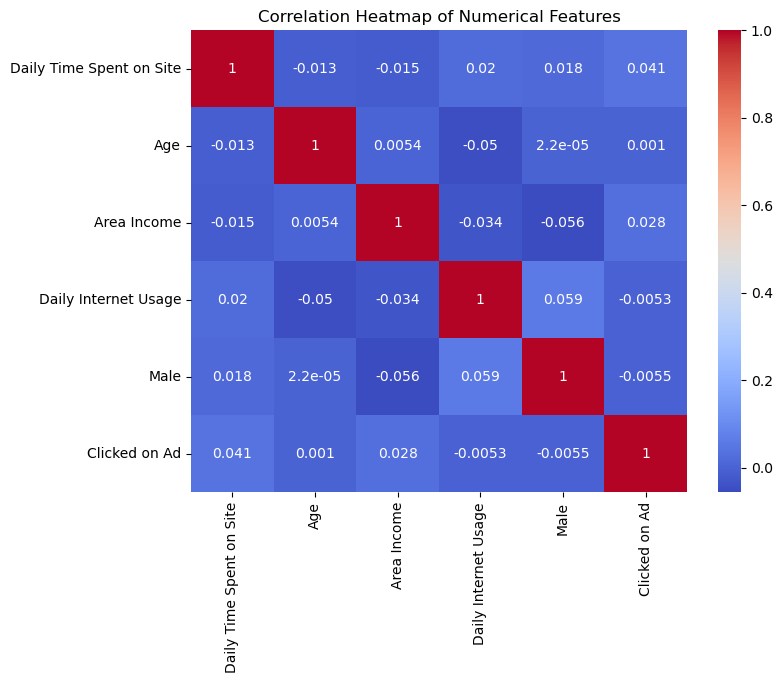

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap of numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

###### Here is the text from the image:


###### Here’s what we can observe from the EDA visuals:

###### Correlation Heatmap:

###### • Daily Time Spent on Site and Daily Internet Usage have a negative correlation with each other.

###### • Clicked on Ad is negatively correlated with Daily Internet Usage and positively correlated with Daily Time Spent on Site and Age.

###### • No multicollinearity issues are apparent.

---


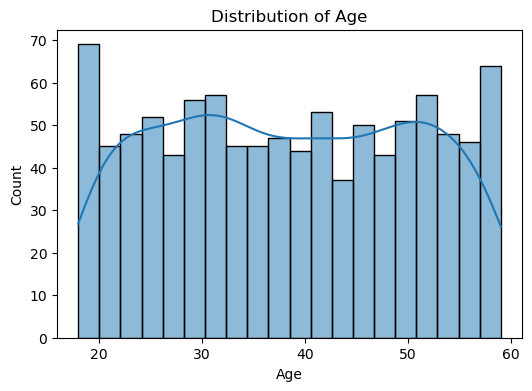

In [11]:
# Distribution of Age
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

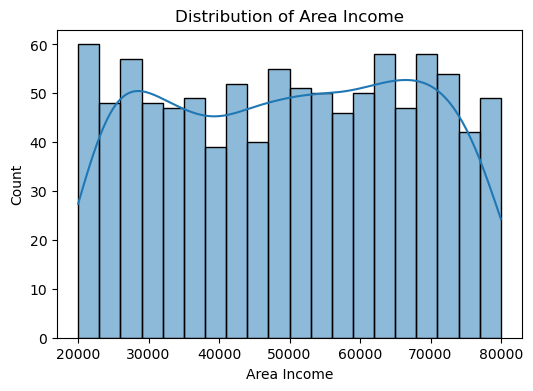

In [12]:
# Distribution of Area Income
plt.figure(figsize=(6, 4))
sns.histplot(df['Area Income'], bins=20, kde=True)
plt.title('Distribution of Area Income')
plt.xlabel('Area Income')
plt.show()

<Axes: xlabel='Daily Time Spent on Site', ylabel='Count'>

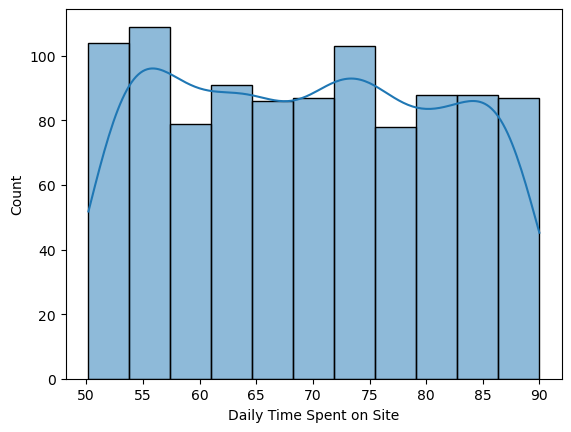

In [13]:
sns.histplot(df['Daily Time Spent on Site'], kde=True)

In [14]:
df['Daily Time Spent on Site'].kurtosis()


np.float64(-1.2292230362330145)

<Axes: xlabel='Daily Internet Usage', ylabel='Count'>

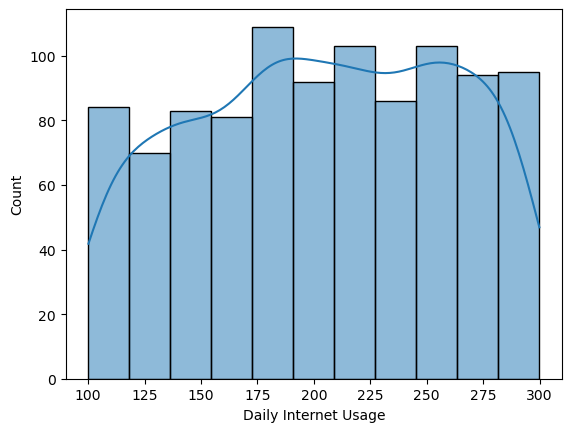

In [15]:
sns.histplot(df['Daily Internet Usage'], kde=True)


In [16]:
df['Daily Internet Usage'].skew()

np.float64(-0.10170643870320355)

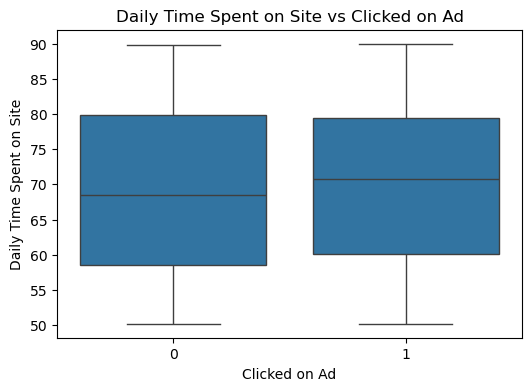

In [17]:
# Boxplot of Daily Time Spent on Site by Clicked on Ad
plt.figure(figsize=(6, 4))
sns.boxplot(x='Clicked on Ad', y='Daily Time Spent on Site', data=df)
plt.title('Daily Time Spent on Site vs Clicked on Ad')
plt.show()

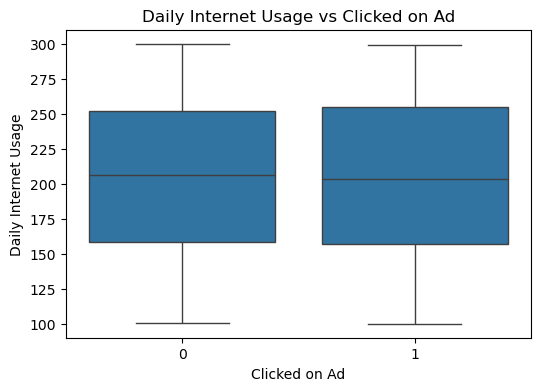

In [18]:
# Boxplot of Daily Internet Usage by Clicked on Ad
plt.figure(figsize=(6, 4))
sns.boxplot(x='Clicked on Ad', y='Daily Internet Usage', data=df)
plt.title('Daily Internet Usage vs Clicked on Ad')
plt.show()

In [19]:
df['Timestamp'].head(3)


0    2025-01-01 00:00:00
1    2025-01-01 01:00:00
2    2025-01-01 02:00:00
Name: Timestamp, dtype: object

In [23]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df['Timestamp'].head(3)


0   2025-01-01 00:00:00
1   2025-01-01 01:00:00
2   2025-01-01 02:00:00
Name: Timestamp, dtype: datetime64[ns]

In [24]:
# Convert 'Timestamp' to datetime and extract new features

df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.dayofweek  # Monday=0, Sunday=6

# Check the new columns
df[['Timestamp', 'Hour', 'Day']].head()

,Timestamp,Hour,Day
0,2025-01-01 00:00:00,0,2
1,2025-01-01 01:00:00,1,2
2,2025-01-01 02:00:00,2,2
3,2025-01-01 03:00:00,3,2
4,2025-01-01 04:00:00,4,2


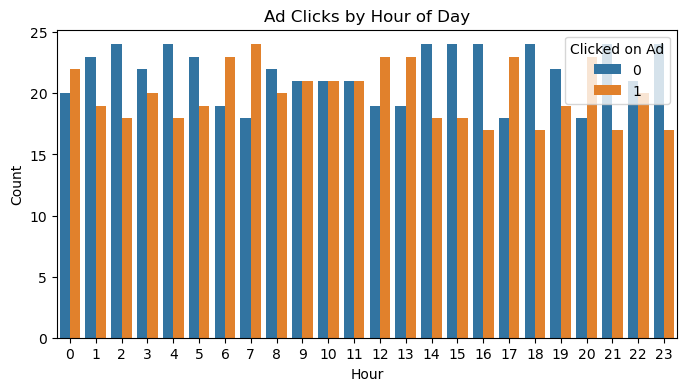

In [25]:
# Clicked on Ad by Hour
plt.figure(figsize=(8, 4))
sns.countplot(x='Hour', hue='Clicked on Ad', data=df)
plt.title('Ad Clicks by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

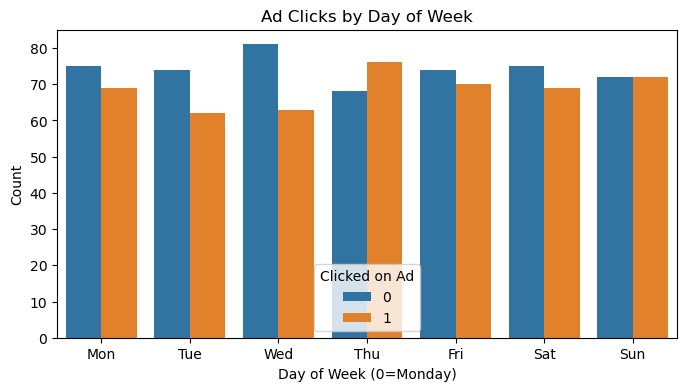

In [26]:
# Clicked on Ad by Day of Week
plt.figure(figsize=(8, 4))
sns.countplot(x='Day', hue='Clicked on Ad', data=df)
plt.title('Ad Clicks by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Count')
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

In [27]:
df['Ad Topic Line'].nunique()

1000

In [28]:
# Define feature set and target
X = df[['Daily Time Spent on Site', 'Age', 'Area Income',
        'Daily Internet Usage', 'Male', 'Hour', 'Day']]
y = df['Clicked on Ad']


In [29]:
from sklearn.linear_model import LogisticRegression

# Initialize and fit Logistic Regression model
logmodel = LogisticRegression(max_iter=1200)#msciter should be more than no of rows
logmodel.fit(X, y)

# Predictions
predictions = logmodel.predict(X)

In [30]:
predictions

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [31]:
df.shape

(1000, 12)

In [35]:
logmodel.score(X,y)#this is accuracy

0.519